In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# Read & save file 
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Check dataframe
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check numerical columns statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Check for null values 
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check each columns data type
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Convert columns to numeric and string data types respectively
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

In [8]:
# Check values in each column
[df[col].value_counts() for col in df]

[customerID
 3186-AJIEK    1
 7590-VHVEG    1
 5575-GNVDE    1
 4501-VCPFK    1
 6075-SLNIL    1
              ..
 1452-KIOVK    1
 6713-OKOMC    1
 7892-POOKP    1
 6388-TABGU    1
 9763-GRSKD    1
 Name: count, Length: 7043, dtype: int64,
 gender
 Male      3555
 Female    3488
 Name: count, dtype: int64,
 SeniorCitizen
 0    5901
 1    1142
 Name: count, dtype: int64,
 Partner
 No     3641
 Yes    3402
 Name: count, dtype: int64,
 Dependents
 No     4933
 Yes    2110
 Name: count, dtype: int64,
 tenure
 1     613
 72    362
 2     238
 3     200
 4     176
      ... 
 28     57
 39     56
 44     51
 36     50
 0      11
 Name: count, Length: 73, dtype: int64,
 PhoneService
 Yes    6361
 No      682
 Name: count, dtype: int64,
 MultipleLines
 No                  3390
 Yes                 2971
 No phone service     682
 Name: count, dtype: int64,
 InternetService
 Fiber optic    3096
 DSL            2421
 No             1526
 Name: count, dtype: int64,
 OnlineSecurity
 No            

In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [10]:
# Create two empty lists
obj = []
inf = []

# Loop through columns, filter & store column names by type 

for col in df:
    if df[col].dtype == 'object':
        obj.append(col)
    else:
        inf.append(col)

In [11]:
# Check index of column
obj.index('Churn')

# Remove columns from list
obj.pop(17), obj.pop(0) 

('Churn', 'customerID')

In [12]:
# Import Fast AI
from fastai.tabular.all import *

In [13]:
# Create a TabularPandas object
to = TabularPandas(
    df,
    procs=[Categorify, FillMissing, Normalize],
    cat_names=obj,
    cont_names=inf,
    y_names='Churn',
    y_block=CategoryBlock(),
    splits=RandomSplitter(valid_pct=0.2, seed=42)(range_of(df)),
)

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)


In [14]:
# Load data
dls = to.dataloaders()

In [15]:
from fastai.metrics import *

# Create a learner object
learn = tabular_learner(dls, layers=[200,100], 
                       metrics=[accuracy, error_rate, F1Score(average='macro')])


0.033113110810518265

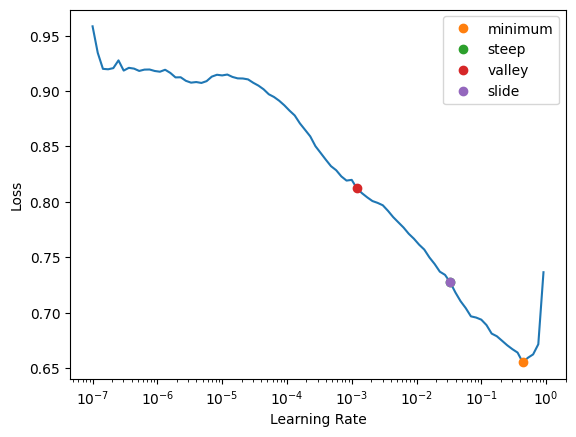

In [16]:
# Find optimal learning rate 
lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))[1]  
lr

In [17]:
# Train model
learn.fit_one_cycle(3, lr_max=lr)

epoch,train_loss,valid_loss,accuracy,error_rate,f1_score,time
0,0.469691,0.456708,0.792614,0.207386,0.704779,00:01
1,0.422967,0.419192,0.805398,0.194602,0.702523,00:00
2,0.414033,0.417374,0.801136,0.198864,0.717534,00:00


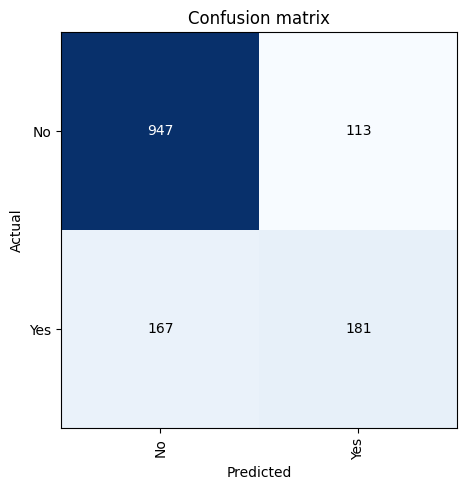

In [18]:
# Plot confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

In [19]:
!pip install "fastinference[interp]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 7.0 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for shap: filename=shap-0.35.0-cp312-cp312-linux_x86_64.whl size=392467 sha256=1e44808377e7d209f8ae77fb2f049118d8f6b163f195373128e2af827538cf50
  Stored in directory: /root/.cache/pip/wheels/af/b9/a8/1f27f2d943f9c335e16a49b2fb541c9c23f1980573472eb387
Successfully built shap
  Attempting uninstall: shap
    Found existing installation: shap 0.49.1
    Uninstalling shap-0.49.1:
      Successfully uninstalled shap-0.49.1


In [20]:
import numpy as np

# Re-inject attributes removed in NumPy 1.24+ and 2.0
np.int = int
np.float = float
np.bool = bool
np.bool8 = np.bool_
np.object = object

# Fix NumPy 2.0 obj2sctype error
if not hasattr(np, 'obj2sctype'):
    np.obj2sctype = lambda obj: np.dtype(obj).type

from fastinference.tabular import *


Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.


In [21]:
!pip install -U shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.2 MB/s eta 0:00:0000:01
  Attempting uninstall: shap
    Found existing installation: shap 0.35.0
    Uninstalling shap-0.35.0:
      Successfully uninstalled shap-0.35.0


A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




  0%|          | 0/100 [00:00<?, ?it/s]

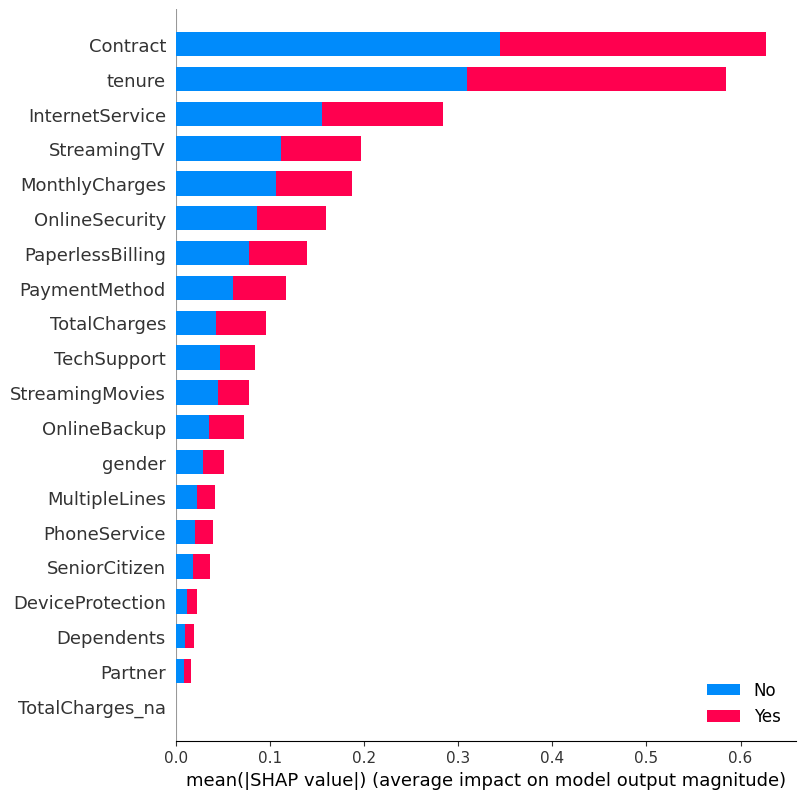

In [22]:
exp = ShapInterpretation(learn, df.iloc[:100])

# Visualize the global feature importance
exp.summary_plot()

In [23]:
# Selects only the SHAP values for the positive class (class 1)
abs_shap = np.abs(exp.shap_vals[1]).mean(axis=0) 

# 2. Create a sorted DataFrame of feature importance
feature_importance = pd.DataFrame({
    'feature': exp.test_data.columns,
    'importance': abs_shap
}).sort_values(by='importance', ascending=False)

# 3. Select top n
top_features = feature_importance.head(10)['feature'].tolist()
print(top_features)

['Contract', 'tenure', 'InternetService', 'StreamingTV', 'MonthlyCharges', 'OnlineSecurity', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'TechSupport']


A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




epoch,train_loss,valid_loss,accuracy,error_rate,f1_score,time
0,0.471052,0.538209,0.776278,0.223722,0.717788,00:00
1,0.435008,0.484525,0.772727,0.227273,0.714006,00:00
2,0.425220,0.423744,0.794034,0.205966,0.708086,00:00


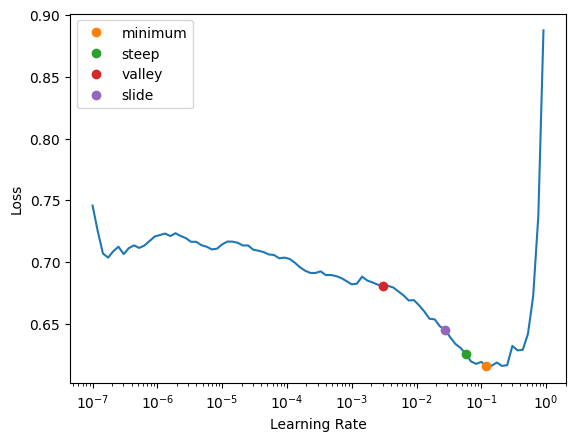

In [24]:
# 1. Filter existing lists to keep only the Top n
new_obj = [col for col in obj if col in top_features]
new_inf = [col for col in inf if col in top_features]

# 2. Re-create the TabularPandas object with the reduced features
to_new = TabularPandas(
    df,
    procs=[Categorify, FillMissing, Normalize],
    cat_names=new_obj,    
    cont_names=new_inf,   
    y_names='Churn',
    y_block=CategoryBlock(),
    splits=RandomSplitter(valid_pct=0.2, seed=42)(range_of(df)),
)

# 3. Create new DataLoaders
dls_new = to_new.dataloaders(bs=64)

# 4. Initialize and train the new Learner
learn_new = tabular_learner(dls_new, layers=[200,100], 
                           metrics=[accuracy, error_rate, F1Score(average='macro')])

# Find the new learning rate (it may change with fewer features)
lr_new = learn_new.lr_find(suggest_funcs=(minimum, steep, valley, slide))[1]

learn_new.fit_one_cycle(3, lr_max=lr_new)


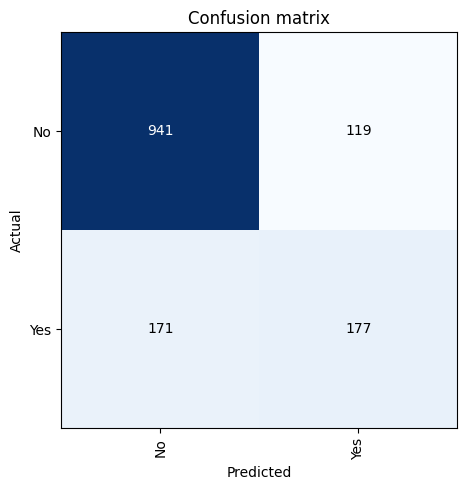

In [25]:
# Plot confusion matrix
interp_new = ClassificationInterpretation.from_learner(learn_new)
interp_new.plot_confusion_matrix()

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




  0%|          | 0/100 [00:00<?, ?it/s]

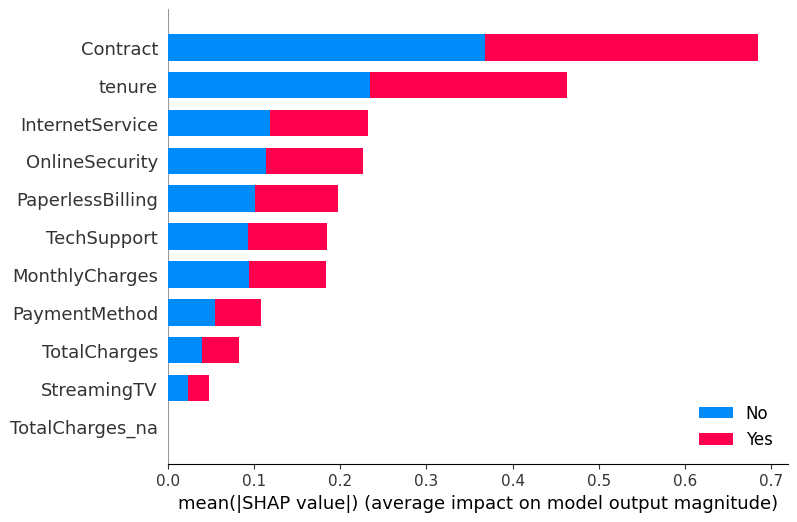

In [26]:
exp2 = ShapInterpretation(learn_new, df.iloc[:100])

# Visualize the global feature importance
exp2.summary_plot()

In [27]:
# Export model
learn_new.export('churn_model.pkl') 

In [29]:
df['TotalCharges'].max()

8684.8